正片叠底

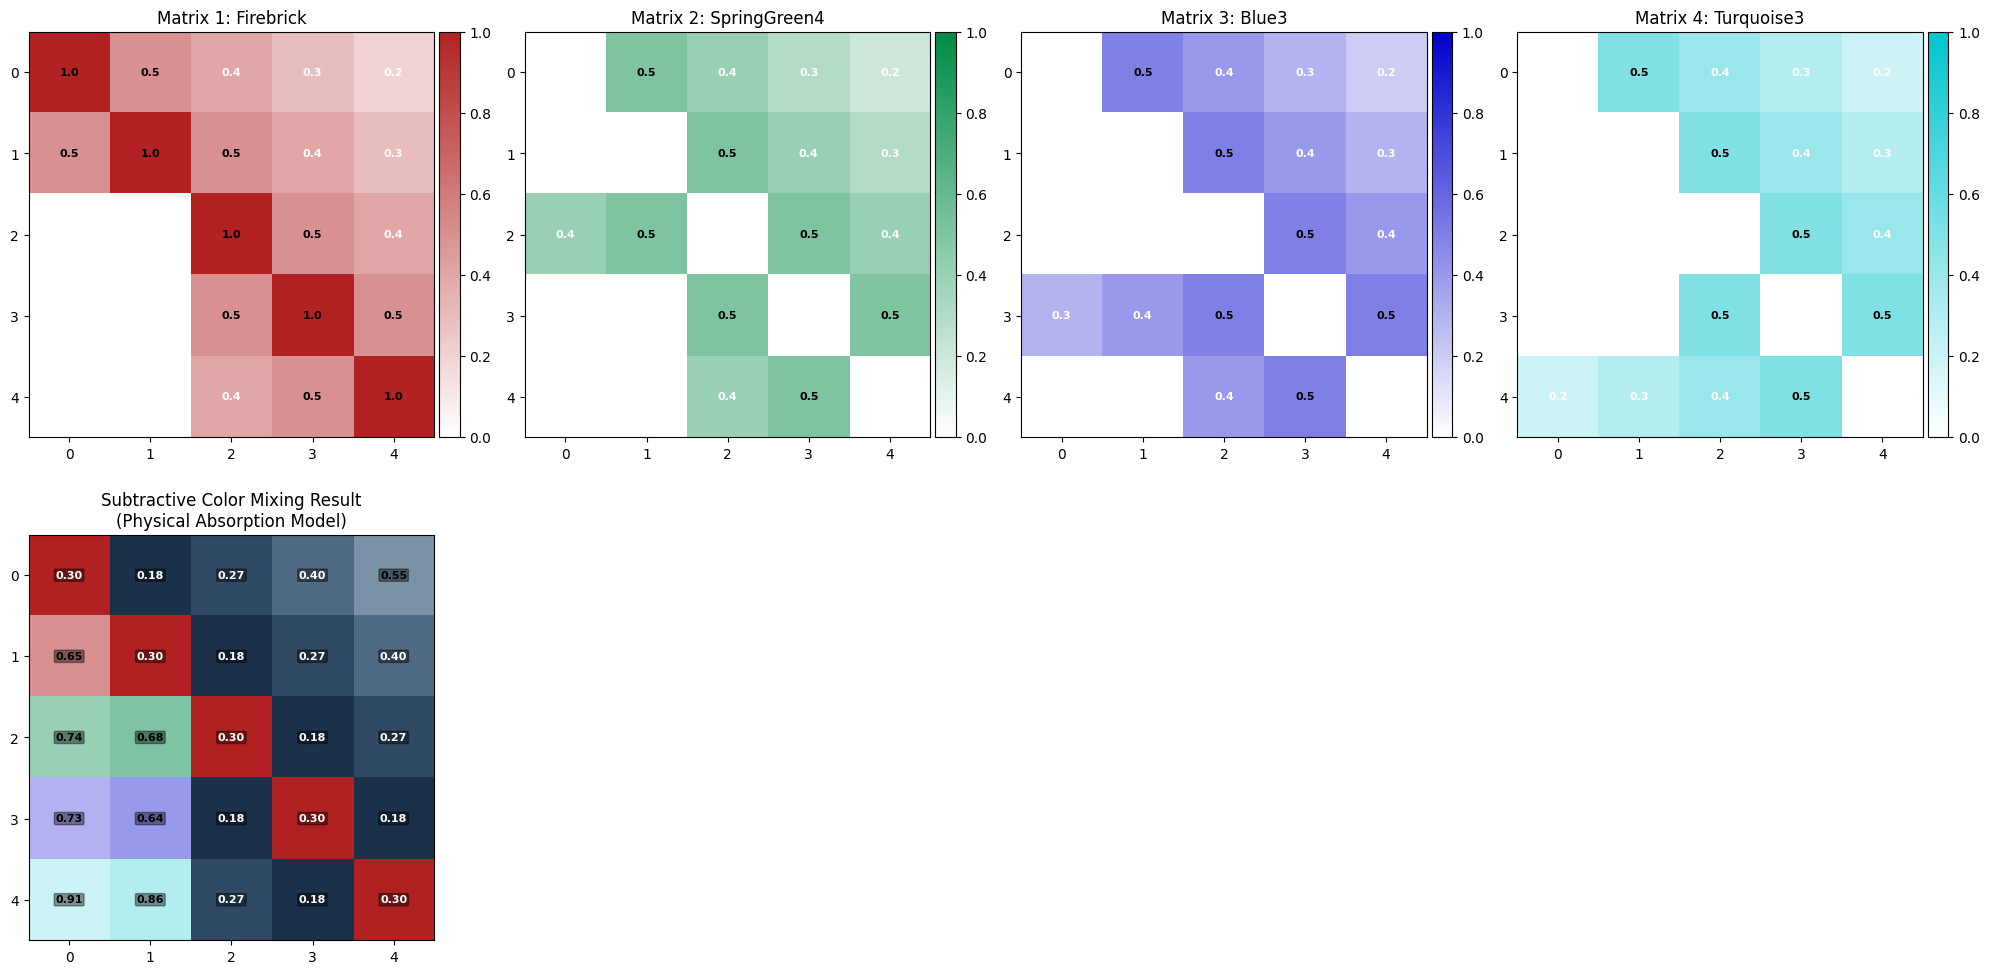

减色混合物理模型说明:
- 算法根据每种颜色的真实 RGB 值，计算其对红、绿、蓝三原色光的【吸收率】(1 - RGB值)
- 例如: 砖红色(#B22222)的G和B值很低，因此它被计算为强烈吸收绿光和蓝光
- 模拟过程: 初始光线为白光(1,1,1)，依次穿过四层带有不同浓度(matrix值)的滤镜
- 最终呈现的颜色 = 剩余未被吸收的光的叠加


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(42)

# 1. 原始数据
matrix1 = np.array([[1.0, 0.5, 0.4, 0.3, 0.2],
                    [0.5, 1.0, 0.5, 0.4, 0.3],
                    [0.0, 0.0, 1.0, 0.5, 0.4],
                    [0.0, 0.0, 0.5, 1.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 1.0]])
matrix2 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
                    [0.0, 0.0, 0.5, 0.4, 0.3],
                    [0.4, 0.5, 0.0, 0.5, 0.4],
                    [0.0, 0.0, 0.5, 0.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 0.0]])
matrix3 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
                    [0.0, 0.0, 0.5, 0.4, 0.3],
                    [0.0, 0.0, 0.0, 0.5, 0.4],
                    [0.3, 0.4, 0.5, 0.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 0.0]])
matrix4 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
                    [0.0, 0.0, 0.5, 0.4, 0.3],
                    [0.0, 0.0, 0.0, 0.5, 0.4],
                    [0.0, 0.0, 0.5, 0.0, 0.5],
                    [0.2, 0.3, 0.4, 0.5, 0.0]])

# 2. 颜色定义与颜色映射
color_defs = {
    "Firebrick": "#B22222",
    "SpringGreen4": "#008B45",
    "Blue3": "#0000CD",
    "Turquoise3": "#00C5CD"
}

cmaps = {name: LinearSegmentedColormap.from_list(f'{name}_cmap', ['white', hex_color]) 
         for name, hex_color in color_defs.items()}

# 3. 核心改进：科学的减色混合函数
def subtractive_mix(matrices, color_hexes):
    """
    基于实际颜色RGB值计算吸收率的减色混合模型
    """
#     r_channel = np.ones((5, 5))
#     g_channel = np.ones((5, 5))
#     b_channel = np.ones((5, 5))
    
    r_channel = np.ones_like(matrices[1])
    g_channel = np.ones_like(matrices[1])
    b_channel = np.ones_like(matrices[1])
    
    for matrix, hex_color in zip(matrices, color_hexes):
        # 将十六进制颜色转为 0-1 范围的 RGB
        r, g, b = to_rgb(hex_color)
        
        # 物理逻辑：颜色越深（RGB值越小），吸收该通道光的能力越强
        # 吸收率 = 1 - 发射/反射率
        absorb_r = 1 - r
        absorb_g = 1 - g
        absorb_b = 1 - b
        
        # 叠加滤镜效果（光线穿过一层层颜料，剩余光相乘）
        r_channel *= (1 - absorb_r * matrix)
        g_channel *= (1 - absorb_g * matrix)
        b_channel *= (1 - absorb_b * matrix)
    
    # 确保值在[0,1]范围内
    rgb_image = np.stack([np.clip(r_channel, 0, 1), 
                          np.clip(g_channel, 0, 1), 
                          np.clip(b_channel, 0, 1)], axis=-1)
    return rgb_image

# 4. 辅助函数：在子图上添加文字（消除重复代码）
def add_matrix_text(ax, data, is_rgb=False):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if is_rgb:
                # 如果是RGB图，计算感知亮度决定文字颜色，显示亮度值
                r, g, b = data[i, j]
                val = 0.299 * r + 0.587 * g + 0.114 * b  # 标准亮度公式
                text_color = 'white' if val < 0.5 else 'black'
                txt = f'{val:.2f}'
                bbox = dict(boxstyle="round,pad=0.1", facecolor='black', alpha=0.4)
            else:
                val = data[i, j]
                text_color = 'white' if val < 0.5 else 'black'
                txt = f'{val:.1f}'  # 单通道保留一位小数即可，避免过于拥挤
                bbox = None
                
            ax.text(j, i, txt, ha='center', va='center', 
                    color=text_color, fontsize=8, weight='bold', bbox=bbox)

# 5. 绘图执行
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

matrices = [matrix1, matrix2, matrix3, matrix4]
names = list(color_defs.keys())

# 绘制前四个单色矩阵
for i in range(4):
    im = axes[i].imshow(matrices[i], cmap=cmaps[names[i]], interpolation='nearest', vmin=0, vmax=1)
    axes[i].set_title(f"Matrix {i+1}: {names[i]}", fontsize=12)
    divider = make_axes_locatable(axes[i])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    add_matrix_text(axes[i], matrices[i])

# 执行混合 (修复了参数未使用的Bug)
mixed_image = subtractive_mix(matrices, list(color_defs.values()))

# 绘制混合结果
axes[4].imshow(mixed_image, interpolation='nearest')
axes[4].set_title('Subtractive Color Mixing Result\n(Physical Absorption Model)', fontsize=12)

# 强制对齐：分配隐形占位空间
divider5 = make_axes_locatable(axes[4])
cax5 = divider5.append_axes("right", size="5%", pad=0.05)
cax5.set_visible(False)

# 在混合图上显示亮度值（逻辑修正）
add_matrix_text(axes[4], mixed_image, is_rgb=True)

# 隐藏空子图
axes[5].set_visible(False)
axes[6].set_visible(False)
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

print("减色混合物理模型说明:")
print("- 算法根据每种颜色的真实 RGB 值，计算其对红、绿、蓝三原色光的【吸收率】(1 - RGB值)")
print("- 例如: 砖红色(#B22222)的G和B值很低，因此它被计算为强烈吸收绿光和蓝光")
print("- 模拟过程: 初始光线为白光(1,1,1)，依次穿过四层带有不同浓度(matrix值)的滤镜")
print("- 最终呈现的颜色 = 剩余未被吸收的光的叠加")

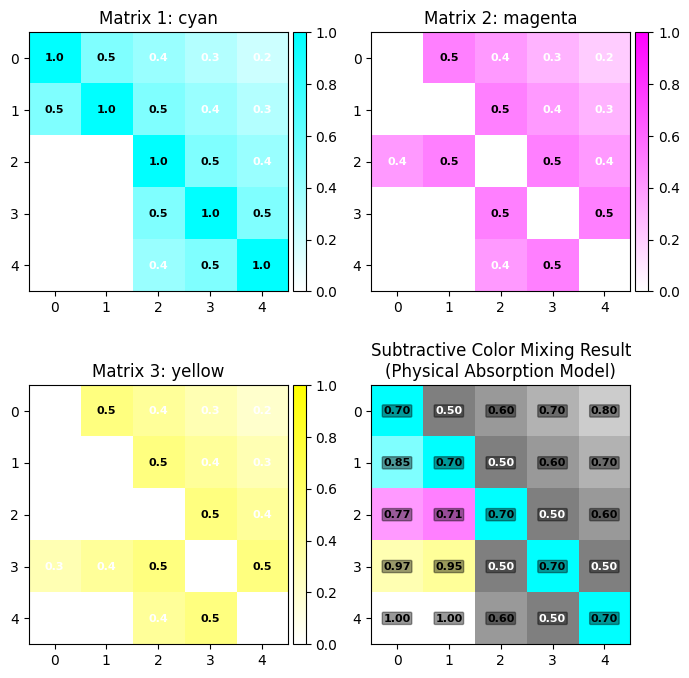

减色混合物理模型说明:
- 算法根据每种颜色的真实 RGB 值，计算其对红、绿、蓝三原色光的【吸收率】(1 - RGB值)
- 例如: 砖红色(#B22222)的G和B值很低，因此它被计算为强烈吸收绿光和蓝光
- 模拟过程: 初始光线为白光(1,1,1)，依次穿过四层带有不同浓度(matrix值)的滤镜
- 最终呈现的颜色 = 剩余未被吸收的光的叠加


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(42)

# 1. 原始数据
matrix1 = np.array([[1.0, 0.5, 0.4, 0.3, 0.2],
                    [0.5, 1.0, 0.5, 0.4, 0.3],
                    [0.0, 0.0, 1.0, 0.5, 0.4],
                    [0.0, 0.0, 0.5, 1.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 1.0]])
matrix2 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
                    [0.0, 0.0, 0.5, 0.4, 0.3],
                    [0.4, 0.5, 0.0, 0.5, 0.4],
                    [0.0, 0.0, 0.5, 0.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 0.0]])
matrix3 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
                    [0.0, 0.0, 0.5, 0.4, 0.3],
                    [0.0, 0.0, 0.0, 0.5, 0.4],
                    [0.3, 0.4, 0.5, 0.0, 0.5],
                    [0.0, 0.0, 0.4, 0.5, 0.0]])
# matrix4 = np.array([[0.0, 0.5, 0.4, 0.3, 0.2],
#                     [0.0, 0.0, 0.5, 0.4, 0.3],
#                     [0.0, 0.0, 0.0, 0.5, 0.4],
#                     [0.0, 0.0, 0.5, 0.0, 0.5],
#                     [0.2, 0.3, 0.4, 0.5, 0.0]])

# 2. 颜色定义与颜色映射
color_defs = {
    "cyan": "cyan",
    "magenta": "magenta",
    "yellow": "yellow"
}

cmaps = {name: LinearSegmentedColormap.from_list(f'{name}_cmap', ['white', hex_color]) 
         for name, hex_color in color_defs.items()}

# 3. 核心改进：科学的减色混合函数
def subtractive_mix(matrices, color_hexes):
    """
    基于实际颜色RGB值计算吸收率的减色混合模型
    """
#     r_channel = np.ones((5, 5))
#     g_channel = np.ones((5, 5))
#     b_channel = np.ones((5, 5))
    
    r_channel = np.ones_like(matrices[1])
    g_channel = np.ones_like(matrices[1])
    b_channel = np.ones_like(matrices[1])
    
    for matrix, hex_color in zip(matrices, color_hexes):
        # 将十六进制颜色转为 0-1 范围的 RGB
        r, g, b = to_rgb(hex_color)
        
        # 物理逻辑：颜色越深（RGB值越小），吸收该通道光的能力越强
        # 吸收率 = 1 - 发射/反射率
        absorb_r = 1 - r
        absorb_g = 1 - g
        absorb_b = 1 - b
        
        # 叠加滤镜效果（光线穿过一层层颜料，剩余光相乘）
        r_channel *= (1 - absorb_r * matrix)
        g_channel *= (1 - absorb_g * matrix)
        b_channel *= (1 - absorb_b * matrix)
    
    # 确保值在[0,1]范围内
    rgb_image = np.stack([np.clip(r_channel, 0, 1), 
                          np.clip(g_channel, 0, 1), 
                          np.clip(b_channel, 0, 1)], axis=-1)
    return rgb_image

# 4. 辅助函数：在子图上添加文字（消除重复代码）
def add_matrix_text(ax, data, is_rgb=False):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if is_rgb:
                # 如果是RGB图，计算感知亮度决定文字颜色，显示亮度值
                r, g, b = data[i, j]
                val = 0.299 * r + 0.587 * g + 0.114 * b  # 标准亮度公式
                text_color = 'white' if val < 0.5 else 'black'
                txt = f'{val:.2f}'
                bbox = dict(boxstyle="round,pad=0.1", facecolor='black', alpha=0.4)
            else:
                val = data[i, j]
                text_color = 'white' if val < 0.5 else 'black'
                txt = f'{val:.1f}'  # 单通道保留一位小数即可，避免过于拥挤
                bbox = None
                
            ax.text(j, i, txt, ha='center', va='center', 
                    color=text_color, fontsize=8, weight='bold', bbox=bbox)

# 5. 绘图执行
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.flatten()

matrices = [matrix1, matrix2, matrix3]
names = list(color_defs.keys())

# 绘制前四个单色矩阵
for i in range(3):
    im = axes[i].imshow(matrices[i], cmap=cmaps[names[i]], interpolation='nearest', vmin=0, vmax=1)
    axes[i].set_title(f"Matrix {i+1}: {names[i]}", fontsize=12)
    divider = make_axes_locatable(axes[i])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    add_matrix_text(axes[i], matrices[i])

# 执行混合 (修复了参数未使用的Bug)
mixed_image = subtractive_mix(matrices, list(color_defs.values()))

# 绘制混合结果
axes[3].imshow(mixed_image, interpolation='nearest')
axes[3].set_title('Subtractive Color Mixing Result\n(Physical Absorption Model)', fontsize=12)

# 强制对齐：分配隐形占位空间
divider4 = make_axes_locatable(axes[3])
cax4 = divider4.append_axes("right", size="5%", pad=0.05)
cax4.set_visible(False)

# 在混合图上显示亮度值（逻辑修正）
add_matrix_text(axes[3], mixed_image, is_rgb=True)

# # 隐藏空子图
# axes[5].set_visible(False)
# axes[6].set_visible(False)
# axes[7].set_visible(False)

plt.tight_layout()
plt.show()

print("减色混合物理模型说明:")
print("- 算法根据每种颜色的真实 RGB 值，计算其对红、绿、蓝三原色光的【吸收率】(1 - RGB值)")
print("- 例如: 砖红色(#B22222)的G和B值很低，因此它被计算为强烈吸收绿光和蓝光")
print("- 模拟过程: 初始光线为白光(1,1,1)，依次穿过四层带有不同浓度(matrix值)的滤镜")
print("- 最终呈现的颜色 = 剩余未被吸收的光的叠加")